# Datasheet PMOS LV — `sg13_lv_pmos` (IHP SG13G2)

**PySpice + modèles OSDI (PSP103) dans Docker, tracé natif macOS.**

This datasheet does not refers to actual measurements

This datasheet can be tuned to reflect the design choices (W, L, Temperature)

Choose the desired corner : mos_ss / mos_tt / mos_ff 

In [1]:
# ═══════════════════════════════════════════════════════════════════
#  Device Parameters
# ═══════════════════════════════════════════════════════════════════
W = 10e-6          # largeur de grille (m)
L = 0.45e-6       # longueur de grille (m) — 0.13µ = L min du LV
CORNER = "mos_tt" # corner process : mos_tt, mos_ss, mos_ff, ...
VBS = 0.0         # polarisation substrat (V)
TEMP_C = 27       # température de simulation (°C)
VGS_ON = 1.2      # V — tension de grille "on" pour Rdson (nominal LV)

# Plage de température du PDK (spec process §1.2 : -40°C < T < 125°C)
TEMP_MIN_PDK, TEMP_MAX_PDK = -40, 125

# Monte Carlo (variation process globale, sections *_stat du PDK)
N_MC = 300        # nombre de tirages
MC_SEED = 42      # graine — reproductibilité des tirages

# Définition datasheet du seuil : critère à courant constant (cf. section VgsTh)
JTH = 100e-9      # A — VgsTh : Vgs tel que Id = JTH × W/L à Vds = 50 mV (critère industriel classique)
# ═══════════════════════════════════════════════════════════════════

import os
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PySpice.Spice.Netlist import Circuit

# --- Chemins -----------------------------------------------------------------
SNIPPET_DIR = Path.cwd()                      # lancer le notebook depuis 08_datasheets/
TOOLKIT_ROOT = SNIPPET_DIR.parents[1]         # .../ihp-macos-toolkit
SCRIPTS_DIR = TOOLKIT_ROOT / "scripts"
PDK_ROOT = Path(os.environ.get("PDK_ROOT", "/Users/lionel/1BIT/OPENHW/IHP-Open-PDK"))

CORNER_LIB = PDK_ROOT / "ihp-sg13g2/libs.tech/ngspice/models/cornerMOSlv.lib"
OSDI = PDK_ROOT / "ihp-sg13g2/libs.tech/verilog-a/psp103/psp103_nqs.osdi"

RESULTS = SNIPPET_DIR / "results"
TMP = SNIPPET_DIR / "tmp"                     # TMPDIR partageable avec Docker
RESULTS.mkdir(exist_ok=True)
TMP.mkdir(exist_ok=True)

# --- Style des tracés ----------------------------------------------------------
plt.rcParams.update({
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.dpi": 110,
})

assert CORNER_LIB.exists(), f"PDK introuvable : {CORNER_LIB}"
assert OSDI.exists(), "OSDI manquant — lancer scripts/compile-va-models.sh"
print(f"PDK  : {PDK_ROOT}")
print(f"DUT  : sg13_lv_nmos  W={W*1e6:.2g}µ  L={L*1e6:.2g}µ  corner={CORNER}  Vbs={VBS}V  T={TEMP_C}°C")

PDK  : /Users/lionel/1BIT/OPENHW/IHP-Open-PDK
DUT  : sg13_lv_nmos  W=10µ  L=0.45µ  corner=mos_tt  Vbs=0.0V  T=27°C


## Le circuit en PySpice, l'exécution en Docker

Trois fonctions :

- `build_circuit()` — le circuit **as code** : PySpice construit le netlist (sources, instance `X1`, `.lib` du corner). C'est ici qu'on changerait W/L, le corner, ou qu'on ajouterait un second transistor.
- `make_netlist()` — ajoute le bloc `.control` (chargement OSDI + analyse + `wrdata`) et écrit le fichier `.sp` dans `results/`.
- `run_ngspice()` — appelle le wrapper `ngspice-docker-python` avec `TMPDIR` forcé dans le projet, puis recharge les données écrites par `wrdata`.

Le **sweep DC imbriqué** de ngspice (`dc Vds start stop step Vgs start stop step`) fait toute la simulation paramétrique **en un seul run Docker** : les courbes sont concaténées dans le fichier de sortie, on les sépare en détectant le redémarrage de la variable de balayage.

In [2]:
def build_circuit(vgs=0.0, vds=0.0, vbs=VBS, temp=None, corner=None):
    """NMOS LV + trois sources de tension (grille, drain, substrat)."""
    c = Circuit("NMOS LV sg13g2 datasheet")
    c.raw_spice = f".lib {CORNER_LIB} {CORNER if corner is None else corner}\n.temp {TEMP_C if temp is None else temp}"
    c.V("gs", "G", c.gnd, vgs)
    c.V("ds", "D", c.gnd, vds)
    c.V("bs", "B", c.gnd, vbs)
    c.X("1", "sg13_lv_nmos", "D", "G", c.gnd, "B", w=W, l=L, ng=1, m=1)
    return c


def make_netlist(circuit, control_lines, name):
    """Netlist PySpice + bloc .control (OSDI, analyse, wrdata) -> results/<name>.sp"""
    control = "\n".join([".control", f"pre_osdi {OSDI}", *control_lines, "quit", ".endc"])
    path = RESULTS / f"{name}.sp"
    path.write_text(str(circuit) + control + "\n.end\n")
    return path


def run_ngspice(netlist_path, datafile):
    """Simule via Docker et renvoie le contenu du fichier wrdata (colonnes numpy)."""
    env = dict(os.environ, TMPDIR=str(TMP), PDK_ROOT=str(PDK_ROOT))
    r = subprocess.run(
        [str(SCRIPTS_DIR / "ngspice-docker-python"), str(netlist_path.relative_to(SNIPPET_DIR))],
        cwd=SNIPPET_DIR, env=env, capture_output=True, text=True, timeout=300,
    )
    if r.returncode != 0:
        print(r.stdout[-2000:])
        print(r.stderr[-2000:])
        raise RuntimeError(f"ngspice a échoué (rc={r.returncode})")
    return np.loadtxt(RESULTS / datafile)


def split_nested_sweep(data):
    """Sépare les courbes d'un sweep DC imbriqué : (x, ids[n_courbes, n_points])."""
    scale = data[:, 0]
    resets = np.where(np.diff(scale) < 0)[0]
    n_inner = (resets[0] + 1) if len(resets) else len(scale)
    return scale[:n_inner], data[:, 1].reshape(-1, n_inner)

## Valeurs limites & parasites — extraits de la spec process (non simulés)

Toute datasheet se termine par les *absolute maximum ratings* et les parasites.
Ceux-ci ne se simulent pas (ou mal) avec notre banc DC : ils sont **repris tels quels
de la spec process** (`SG13G2_os_process_spec.pdf` Rev 1.2 du 2023-12-20, §2.1 p.7-8,
conditions de mesure en Attachment A p.22-24). Device de référence : W×L = 10×0,13 µm².

### Limites absolues

| Grandeur | Nom spec | Min | Cible | Max | Unité | Condition (réf.) |
|---|---|---|---|---|---|---|
| Tension de grille max | — | | | **1,65** | V | $V_{GS}$ ≤ 1,65 V @ 125 °C (en-tête §2.1) |
| Claquage drain-source $BV_{DSS}$ | BVDSSN013 | **2,0** | 2,7 | — | V | $V_{GS}=V_{BS}=0$, $I_D$ = 10 nA/µm (A.f1) |
| Claquage jonction S/D–caisson | BVNPW | | *12* | | V | diode S/D–body, j = 1 mA/cm² (A.f3) |
| Plage de température qualifiée | — | **−40** | | **+125** | °C | §1.2 |

### Parasites & géométrie effective

| Grandeur | Nom spec | Min | Cible | Max | Unité | Condition (réf.) |
|---|---|---|---|---|---|---|
| Capacité de Miller (recouvrement G-D) | CMILLERN | 0,32 | 0,36 | 0,40 | fF/µm | (A.k1) |
| Capacité de jonction S/D | CJUNCTIONN | 0,9 | 0,95 | 1,0 | fF/µm² | V = 0, f = 100 kHz (A.k) |
| Longueur de canal effective | LEFFN013 | 0,10 | 0,14 | 0,19 | µm | L dessinée = 0,13 µm (A.g1) |
| Largeur de canal effective | WEFFN015 | 0,09 | 0,15 | 0,22 | µm | W dessinée = 0,15 µm (A.h1) |

> Rappels d'usage : ces valeurs sont des **paramètres de contrôle process mesurés**
> (« must not be used for circuit simulation purposes », §1.2.2) — pour la simulation,
> les capacités sont dans le modèle PSP103/JUNCAP200 déjà chargé via OSDI. Ordre de
> grandeur utile : pour notre W = 1 µm, Miller ≈ 0,36 fF, à comparer à
> $C_{gg} \approx W·L·C_{ox}$ ≈ 1,8 fF ($T_{ox}$ = 2,45 nm → $C_{ox}$ ≈ 14 fF/µm², §2.16).

**Encore absent de cette datasheet** (candidats aux sections suivantes) : courbes
C-V ($C_{gg}$, $C_{gd}$ vs $V_{GS}$ — simulables en AC, PSP103 exporte ses charges
donc $Q_g$ aussi), $g_m/I_D$ vs inversion, effet substrat $V_{GSth}(V_{BS})$, bruit
(thermique + flicker, cf. snippet 10), et le tout au corner PMOS (§2.2).

## Simulation 3 — extraction aux conditions de la spec process IHP

Process specification (`libs.doc/doc/SG13G2_os_process_spec.pdf`, Rev. 1.2, §2.1 et
Attachment A) provides definitions for NMOS LV parameters. This datasheet will be computed accordingly :

| Parameter | Ref. | Test conditions (Attachment A) |
|---|---|---|
| $V_{th}$ (VTN10x013) | A.a1 | $V_{DS}=50$ mV, $V_t = V_o - V_{DS}/2$ (Linear extrapolation at max. Slope)|
| $I_{D,sat}$ (IDSN013) | A.b1 | $V_{GS}=V_{DS}=1{,}2$ V |
| $I_{off}$ (IOFFN013) | A.c1 | $V_{DS}=1{,}2$ V, $V_{GS}=V_{BS}=0$ |
| DIBL (DIBLN013) | A.d1 | $[V_{GS}(V_{DS1})-V_{GS}(V_{DS2})]/(V_{DS2}-V_{DS1})$ à $I_D=0{,}5$ nA·W/L, $V_{DS}$ = 0,1 / 1,2 V |
| $SS$ (SSN013) | A.e | $V_{DS}=0{,}1$ V, pente entre $I_{D1}=0{,}5$ nA·W/L et $I_{D2}=5$ nA·W/L |

In [23]:
# Two simulations in a single testbench run. Vgs DC sweep @Vds=50mV, then Vgs sweep @Vds=1.2V, second sweep
netlist = make_netlist(
    build_circuit(vds=0.05),
    ["dc Vgs 0 1.5 0.002",
     "wrdata results/spec_vds_50m.txt -i(Vds)",
     "alter Vds 1.2",
     "dc Vgs 0 1.5 0.002",
     "wrdata results/spec_vds_1200m.txt -i(Vds)"],
    "spec_check",
)
run_ngspice(netlist, "spec_vds_50m.txt")
d50 = np.loadtxt(RESULTS / "spec_vds_50m.txt")
d1200 = np.loadtxt(RESULTS / "spec_vds_1200m.txt")
vg, id50, id1200 = d50[:, 0], d50[:, 1], d1200[:, 1]


def vgs_at(x, curve, i_target):
    """Vgs auquel la courbe Id(Vgs) atteint i_target (interpolation en log)."""
    m = curve > 1e-13
    return np.interp(np.log10(i_target), np.log10(curve[m]), x[m])


# --- A.a1 : Vth par extrapolation lineaire au max de pente (Vds=50mV) ---
gm = np.gradient(id50, vg)
k = np.argmax(gm)
vth = (vg[k] - id50[k] / gm[k]) - 0.05 / 2      # Vt = Vo - Vds/2

# --- A.b1 : Idsat a Vgs=Vds=1.2V, en uA/um ---
idsat = np.interp(1.2, vg, id1200) / (W * 1e6) * 1e6

# --- A.c1 : Ioff a Vgs=0, Vds=1.2V, en log10(A/um) ---
ioff = np.log10(id1200[0] / (W * 1e6))

# --- A.d1 : DIBL entre Vds=0.1V et 1.2V a Id = 0.5nA * W/L ---
id_crit = 0.5e-9 * W / L   # critere DIBL de la spec (A.d1), fixe, independant de JTH
dibl = (vgs_at(vgs, ids_vgs[0], id_crit) - vgs_at(vg, id1200, id_crit)) / (1.2 - 0.1) * 1e3

# --- A.e : pente sous le seuil entre 0.5 et 5 nA * W/L (Vds=0.1V, sim 2) ---
ss = vgs_at(vgs, ids_vgs[0], 10 * id_crit) - vgs_at(vgs, ids_vgs[0], id_crit)
ss *= 1e3  # 0.5 -> 5 nA*W/L = 1 decade => SS = dVgs en mV/dec

#SPEC = [  # (nom, valeur simulee, min, cible, max, unite)
#    ("Vth      (VTN10x013)", vth,   0.43, 0.50, 0.55, "V"),
#    ("Id,sat   (IDSN013)  ", idsat, 380,  480,  600,  "µA/µm"),
#    ("log Ioff (IOFFN013) ", ioff,  None, -10,  -9,   "log10(A/µm)"),
#    ("DIBL     (DIBLN013) ", dibl,  20,   50,   80,   "mV/V"),
#    ("SS       (SSN013)   ", ss,    76,   82,   88,   "mV/dec"),
#]

#print(f"sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ ({CORNER}, {TEMP_C}°C)  vs  spec process Rev 1.2 (device 10×0.13µm²)\n")
#print(f"{'Paramètre':<22} {'simulé':>9}   {'min':>6} {'cible':>6} {'max':>6}   unité")
#for name, val, lo, target, hi, unit in SPEC:
#    ok = (lo is None or val >= lo) and (hi is None or val <= hi)
#    print(f"{name:<22} {val:9.3g}   {lo if lo is not None else '—':>6} {target:>6} {hi:>6}   {unit:<12} {'✓' if ok else '✗ hors bornes'}")

MESURES = [  # (grandeur + conditions explicites, valeur, unité)
    ("Vth (ELR, Vds=50mV)",              vth,   "V"),
    ("Id,sat (Vgs=Vds=1.2V)",            idsat, "µA/µm"),
    ("log Ioff (Vgs=0, Vds=1.2V)",       ioff,  "log10(A/µm)"),
    ("DIBL (Id=0.5nA·W/L, 0.1→1.2V)",    dibl,  "mV/V"),
    ("SS (0.5→5 nA·W/L, Vds=0.1V)",      ss,    "mV/dec"),
]
print(f"sg13_lv_nmos  W={W*1e6:.2g}µ  L={L*1e6:.2g}µ  ({CORNER}, {TEMP_C}°C)\n")
for nom, val, unite in MESURES:
    print(f"  {nom:<34} {val:9.3g}   {unite}")

sg13_lv_nmos  W=10µ  L=0.45µ  (mos_tt, 27°C)

  Vth (ELR, Vds=50mV)                    0.303   V
  Id,sat (Vgs=Vds=1.2V)                    289   µA/µm
  log Ioff (Vgs=0, Vds=1.2V)              -9.2   log10(A/µm)
  DIBL (Id=0.5nA·W/L, 0.1→1.2V)           29.4   mV/V
  SS (0.5→5 nA·W/L, Vds=0.1V)             74.8   mV/dec


## $I_{DS}(V_{DS})$ @ $V_{GS}$

$V_{DS}$ balayé de 0 à 1,5 V par pas de 10 mV (sweep interne), $V_{GS}$ de 0,5 à 1,5 V
par pas de 0,2 V (sweep externe) : **6 courbes, 906 points, un seul run Docker**.

In [3]:
netlist = make_netlist(
    build_circuit(),
    ["dc Vds 0 1.5 0.05 Vgs 0.5 1.5 0.2",
     "wrdata results/ids_vds.txt -i(Vds)"],
    "ids_vds",
)
print(netlist.read_text())

vds, ids_vds = split_nested_sweep(run_ngspice(netlist, "ids_vds.txt"))
vgs_levels = np.arange(0.5, 1.51, 0.2)
print(f"{ids_vds.shape[0]} courbes × {ids_vds.shape[1]} points")

.title NMOS LV sg13g2 datasheet
.lib /Users/lionel/1BIT/OPENHW/IHP-Open-PDK/ihp-sg13g2/libs.tech/ngspice/models/cornerMOSlv.lib mos_tt
.temp 27
Vgs G 0 0.0
Vds D 0 0.0
Vbs B 0 0.0
X1 D G 0 B sg13_lv_nmos l=4.5e-07 m=1 ng=1 w=1e-05
.control
pre_osdi /Users/lionel/1BIT/OPENHW/IHP-Open-PDK/ihp-sg13g2/libs.tech/verilog-a/psp103/psp103_nqs.osdi
dc Vds 0 1.5 0.01 Vgs 0.5 1.5 0.2
wrdata results/ids_vds.txt -i(Vds)
quit
.endc
.end

6 courbes × 151 points


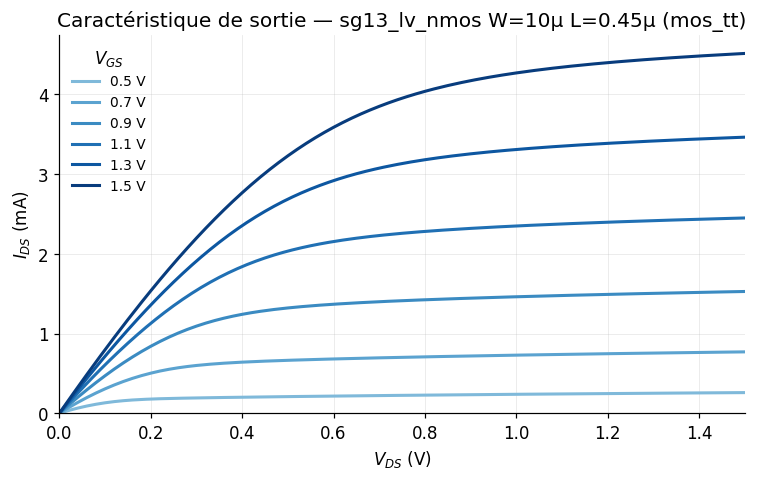

In [4]:
colors = plt.get_cmap("Blues")(np.linspace(0.45, 0.95, len(vgs_levels)))

fig, ax = plt.subplots(figsize=(7, 4.5))
for curve, vgs, color in zip(ids_vds, vgs_levels, colors):
    ax.plot(vds, curve * 1e3, color=color, lw=2, label=f"{vgs:.1f} V")

ax.set_xlabel("$V_{DS}$ (V)")
ax.set_ylabel("$I_{DS}$ (mA)")
ax.set_title(f"Caractéristique de sortie — sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ ({CORNER})")
ax.set_xlim(0, 1.5)
ax.set_ylim(bottom=0)
ax.legend(title="$V_{GS}$", frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "ids_vds.png", dpi=150)
plt.show()

## Simulation 2 — caractéristique de transfert $I_{DS}(V_{GS})$ @ $V_{DS}$

Mêmes sources, mêmes fonctions — on **croise simplement les rôles** des deux sweeps :
$V_{GS}$ devient le sweep interne (0 → 1,5 V, pas de 5 mV), $V_{DS}$ le paramètre
(0,1 → 1,5 V, pas de 0,35 V, soit 5 courbes). Le tracé semilog révèle la conduction
sous le seuil, invisible en linéaire.

In [5]:
netlist = make_netlist(
    build_circuit(),
    ["dc Vgs 0 1.5 0.05 Vds 0.1 1.5 0.35",
     "wrdata results/ids_vgs.txt -i(Vds)"],
    "ids_vgs",
)
vgs, ids_vgs = split_nested_sweep(run_ngspice(netlist, "ids_vgs.txt"))
vds_levels = np.arange(0.1, 1.51, 0.35)
print(f"{ids_vgs.shape[0]} courbes × {ids_vgs.shape[1]} points")

5 courbes × 301 points


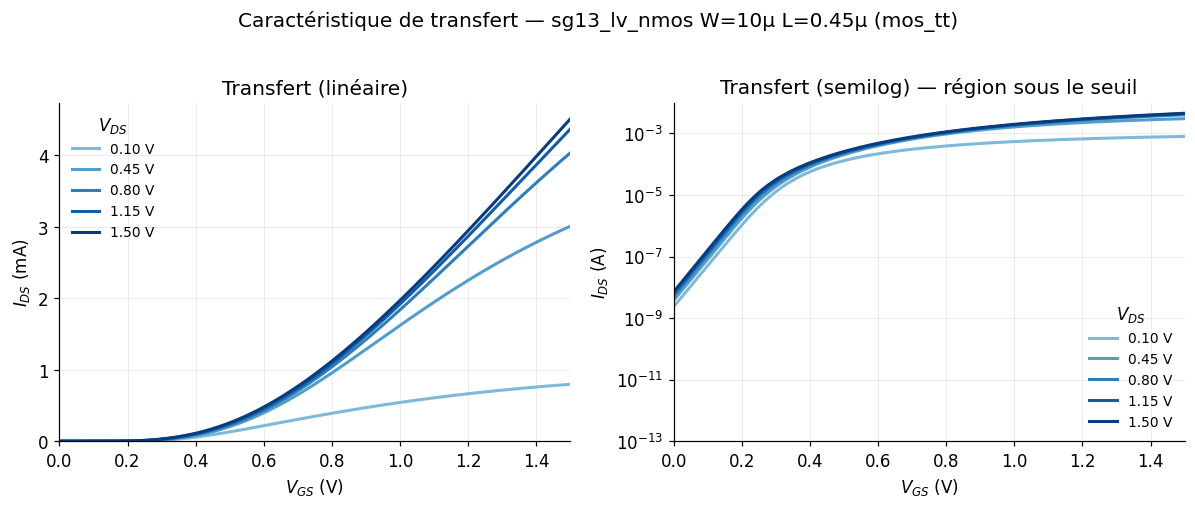

In [6]:
colors = plt.get_cmap("Blues")(np.linspace(0.45, 0.95, len(vds_levels)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for curve, vd, color in zip(ids_vgs, vds_levels, colors):
    ax1.plot(vgs, curve * 1e3, color=color, lw=2, label=f"{vd:.2f} V")
    ax2.semilogy(vgs, np.abs(curve), color=color, lw=2, label=f"{vd:.2f} V")

ax1.set_xlabel("$V_{GS}$ (V)")
ax1.set_ylabel("$I_{DS}$ (mA)")
ax1.set_title("Transfert (linéaire)")
ax1.set_xlim(0, 1.5)
ax1.set_ylim(bottom=0)
ax1.legend(title="$V_{DS}$", frameon=False, loc="upper left", fontsize=9)

ax2.set_xlabel("$V_{GS}$ (V)")
ax2.set_ylabel("$I_{DS}$ (A)")
ax2.set_title("Transfert (semilog) — région sous le seuil")
ax2.set_xlim(0, 1.5)
ax2.set_ylim(1e-13, 1e-2)
ax2.legend(title="$V_{DS}$", frameon=False, loc="lower right", fontsize=9)

fig.suptitle(f"Caractéristique de transfert — sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ ({CORNER})", y=1.02)
fig.tight_layout()
fig.savefig(RESULTS / "ids_vgs.png", dpi=150, bbox_inches="tight")
plt.show()

## $R_{DSon}$ et $V_{GSth}$ en température — tableau datasheet

Deuxième grandeur de datasheet, avec sa définition explicite :

> ### $R_{DSon}$ — Drain-Source On-Resistance
> $$R_{DSon} \;\triangleq\; \frac{V_{DS}}{I_D} \;\Big|\; V_{GS} = V_{GS,on}$$
> **Conditions** : $V_{GS,on} = 1{,}2$ V (paramètre `VGS_ON`, grille au nominal LV),
> $V_{DS} = 50$ mV (région linéaire profonde, $V_{DS} \ll V_{GS}-V_{GSth}$), $V_{BS} = 0$.

Le tableau est donné à **trois températures** : les bornes de qualification du PDK
(−40 °C / +125 °C, spec process §1.2) et la température choisie en paramètre (`TEMP_C`).
Un sweep $V_{GS}$ à $V_{DS} = 50$ mV par température suffit pour les deux grandeurs —
trois runs Docker.

Les deux dérives sont de signes opposés, comme attendu : $V_{GSth}$ **baisse** avec T
(≈ −0,7 mV/K) tandis que $R_{DSon}$ **monte** (dégradation de mobilité) — c'est le
croisement de ces deux effets qui crée le point ZTC visible sur la figure.

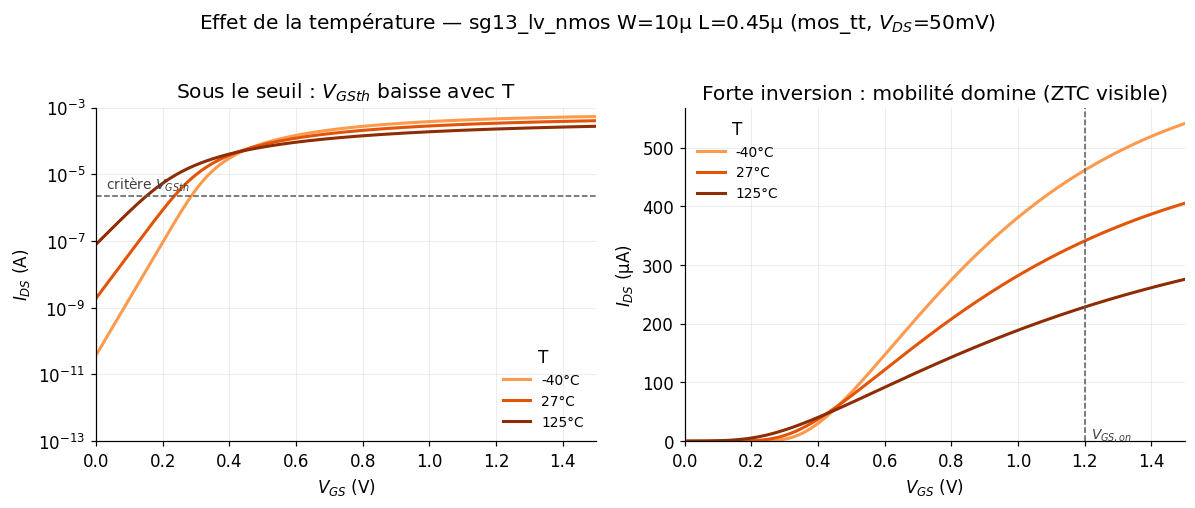

sg13_lv_nmos  W=10µ  L=0.45µ  corner mos_tt  Vbs=0.0V

Paramètre  Conditions                            -40°C       27°C      125°C   unité
VgsTh      Id = 100 nA·W/L, Vds = 50 mV            286        234        151   mV
Rdson      Vgs = 1.2 V, Vds = 50 mV                108        147        219   Ω
Rdson·W    (normalisé largeur)                    1084       1466       2189   Ω·µm


In [9]:
TEMPS = sorted({TEMP_MIN_PDK, TEMP_C, TEMP_MAX_PDK})   # dédoublonné si TEMP_C = borne

sweeps = {}
for T in TEMPS:
    netlist = make_netlist(
        build_circuit(vds=0.05, temp=T),
        ["dc Vgs 0 1.5 0.002", f"wrdata results/rdson_t{T}.txt -i(Vds)"],
        f"rdson_t{T}",
    )
    sweeps[T] = run_ngspice(netlist, f"rdson_t{T}.txt")

vgsth_T, rdson_T = {}, {}
for T, d in sweeps.items():
    x, i = d[:, 0], d[:, 1]
    vgsth_T[T] = vgs_at(x, i, JTH * W / L)
    rdson_T[T] = 0.05 / np.interp(VGS_ON, x, i)

# --- Figure : Id(Vgs) à Vds=50mV aux trois températures ---
colors = plt.get_cmap("Oranges")(np.linspace(0.45, 0.95, len(TEMPS)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for T, color in zip(TEMPS, colors):
    d = sweeps[T]
    ax1.semilogy(d[:, 0], np.abs(d[:, 1]), color=color, lw=2, label=f"{T}°C")
    ax2.plot(d[:, 0], d[:, 1] * 1e6, color=color, lw=2, label=f"{T}°C")
ax1.axhline(JTH * W / L, color="0.35", lw=1, ls="--")
ax1.annotate("critère $V_{GSth}$", (0.03, JTH * W / L * 1.6), fontsize=9, color="0.25")
ax1.set_xlabel("$V_{GS}$ (V)"); ax1.set_ylabel("$I_{DS}$ (A)")
ax1.set_title("Sous le seuil : $V_{GSth}$ baisse avec T")
ax1.set_xlim(0, 1.5); ax1.set_ylim(1e-13, 1e-3)
ax1.legend(title="T", frameon=False, loc="lower right", fontsize=9)
ax2.axvline(VGS_ON, color="0.35", lw=1, ls="--")
ax2.annotate("$V_{GS,on}$", (VGS_ON + 0.02, 5), fontsize=9, color="0.25")
ax2.set_xlabel("$V_{GS}$ (V)"); ax2.set_ylabel("$I_{DS}$ (µA)")
ax2.set_title("Forte inversion : mobilité domine (ZTC visible)")
ax2.set_xlim(0, 1.5); ax2.set_ylim(bottom=0)
ax2.legend(title="T", frameon=False, loc="upper left", fontsize=9)
fig.suptitle(f"Effet de la température — sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ ({CORNER}, $V_{{DS}}$=50mV)", y=1.02)
fig.tight_layout()
fig.savefig(RESULTS / "temperature.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Tableau datasheet ---
head = "".join(f"{T:>9}°C" for T in TEMPS)
print(f"sg13_lv_nmos  W={W*1e6:.2g}µ  L={L*1e6:.2g}µ  corner {CORNER}  Vbs={VBS}V\n")
print(f"{'Paramètre':<10} {'Conditions':<32}{head}   unité")
print(f"{'VgsTh':<10} {f'Id = {JTH*1e9:.0f} nA·W/L, Vds = 50 mV':<32}"
      + "".join(f"{vgsth_T[T]*1e3:>11.0f}" for T in TEMPS) + "   mV")
print(f"{'Rdson':<10} {f'Vgs = {VGS_ON} V, Vds = 50 mV':<32}"
      + "".join(f"{rdson_T[T]:>11.0f}" for T in TEMPS) + "   Ω")
print(f"{'Rdson·W':<10} {'(normalisé largeur)':<32}"
      + "".join(f"{rdson_T[T]*W*1e6:>11.0f}" for T in TEMPS) + "   Ω·µm")


## Effet substrat — $V_{GSth}(V_{BS})$

La troisième source du circuit sert enfin. En polarisation inverse du substrat
($V_{BS} < 0$ pour un NMOS), le seuil monte :

> ### Coefficient d'effet substrat $\gamma$
> $$V_{GSth}(V_{BS}) = V_{GSth,0} + \gamma\left(\sqrt{2\varphi_F - V_{BS}} - \sqrt{2\varphi_F}\right)$$
> **Conventions** : $2\varphi_F = 0{,}8$ V (fixé), $V_{GSth}$ au critère courant constant
> habituel ($J_{th}·W/L$, $V_{DS} = 50$ mV), $V_{BS}$ de 0 à −1,2 V.

Un seul run Docker : sweep imbriqué avec $V_{BS}$ en boucle externe.

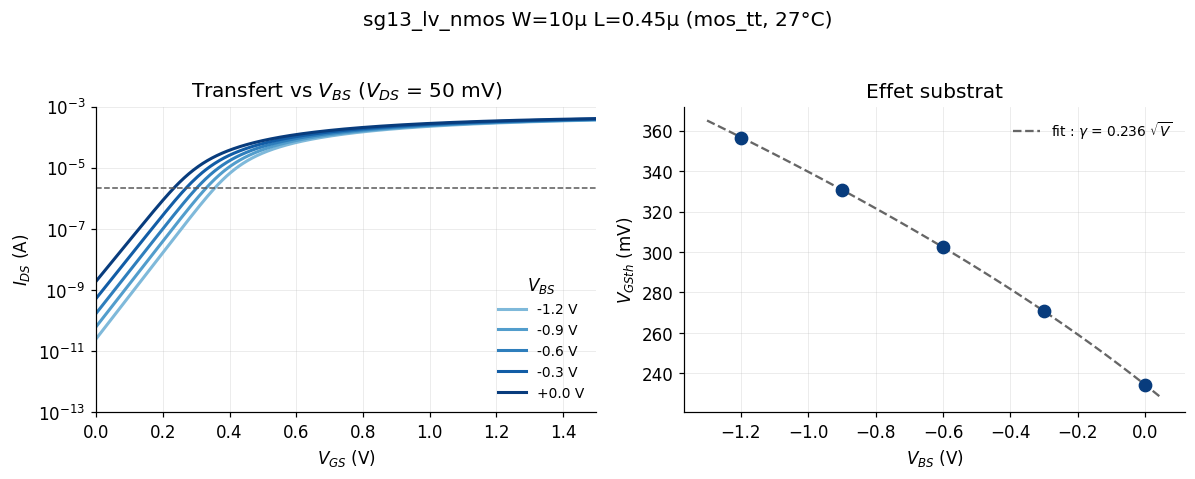

VgsTh : 234 mV (Vbs=0) -> 357 mV (Vbs=-1.2V)
gamma = 0.236 sqrt(V)  (2*phiF fixe = 0.8 V)


In [14]:
netlist = make_netlist(
    build_circuit(vds=0.05),
    ["dc Vgs 0 1.5 0.002 Vbs -1.2 0 0.3",
     "wrdata results/body.txt -i(Vds)"],
    "body",
)
vg_b, ids_b = split_nested_sweep(run_ngspice(netlist, "body.txt"))
vbs_levels = np.arange(-1.2, 0.01, 0.3)
vth_b = np.array([vgs_at(vg_b, c, JTH * W / L) for c in ids_b])

# Fit gamma (2*phiF fixe a 0.8 V)
xb = np.sqrt(0.8 - vbs_levels) - np.sqrt(0.8)
gamma = np.sum(xb * (vth_b - vth_b[-1])) / np.sum(xb**2)

colors = plt.get_cmap("Blues")(np.linspace(0.45, 0.95, len(vbs_levels)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for curve, vb, color in zip(ids_b, vbs_levels, colors):
    ax1.semilogy(vg_b, np.abs(curve), color=color, lw=2, label=f"{vb:+.1f} V")
ax1.axhline(JTH * W / L, color="0.35", lw=1, ls="--")
ax1.set_xlabel("$V_{GS}$ (V)"); ax1.set_ylabel("$I_{DS}$ (A)")
ax1.set_title("Transfert vs $V_{BS}$ ($V_{DS}$ = 50 mV)")
ax1.set_xlim(0, 1.5); ax1.set_ylim(1e-13, 1e-3)
ax1.legend(title="$V_{BS}$", frameon=False, fontsize=9, loc="lower right")

xfit = np.linspace(-1.3, 0.05, 50)
ax2.plot(xfit, (vth_b[-1] + gamma * (np.sqrt(0.8 - xfit) - np.sqrt(0.8))) * 1e3,
         color="0.4", lw=1.5, ls="--",
         label=f"fit : $\\gamma$ = {gamma:.3f} $\\sqrt{{V}}$")
ax2.plot(vbs_levels, vth_b * 1e3, "o", ms=8, color=colors[-1])
ax2.set_xlabel("$V_{BS}$ (V)"); ax2.set_ylabel("$V_{GSth}$ (mV)")
ax2.set_title("Effet substrat")
ax2.legend(frameon=False, fontsize=9)
fig.suptitle(f"sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ ({CORNER}, {TEMP_C}°C)", y=1.03)
fig.tight_layout()
fig.savefig(RESULTS / "body_effect.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"VgsTh : {vth_b[-1]*1e3:.0f} mV (Vbs=0) -> {vth_b[0]*1e3:.0f} mV (Vbs=-1.2V)")
print(f"gamma = {gamma:.3f} sqrt(V)  (2*phiF fixe = 0.8 V)")


## Capacités — $C_{gg}$ et $C_{dg}$ vs $V_{GS}$ (petit signal)

Les capacités « simulées » vivent dans le modèle PSP103 (charges) — on les extrait en
**petit signal** :

> ### $C_{gg}$, $C_{dg}$ — capacités de grille
> Source AC de 1 V sur la grille, $V_{DS} = 0$ (condition de la spec, A.k),
> f = 100 kHz : $C_{xg} = \left|\Im(i_x)\right| / (2\pi f)$, où $i_x$ est le courant
> AC du terminal $x$. Boucle `alter`/`ac` sur le bias $V_{GS}$ — un seul run Docker.

Attendus : plateau d'inversion $C_{gg} \approx C_{ox}·W·L$ + recouvrements ≈ 2 fF ;
à $V_{DS}=0$ le canal se partage 50/50 → $C_{dg} \to C_{gg}/2$ en inversion ;
à l'état bloqué, $C_{dg}$ = recouvrement + fringe, à comparer à la capacité de
Miller de la spec (CMILLERN = 0,32–0,40 fF/µm, mesurée dans une autre configuration —
même ordre de grandeur attendu, pas une égalité).

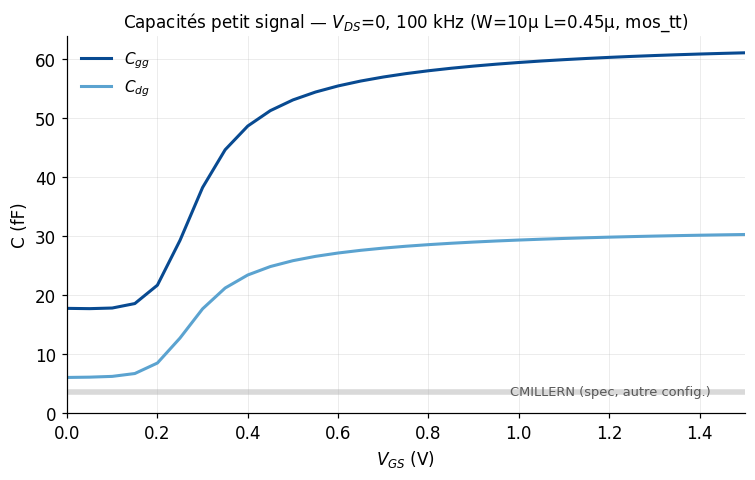

Cgg : 17.75 fF (bloqué) -> 61.04 fF (inversion) ; Cox·W·L ≈ 63.45 fF
Cdg : 6.05 fF (bloqué, recouvrement+fringe) -> 30.26 fF ≈ Cgg/2 (canal partagé à Vds=0)
Miller spec (CMILLERN×W) : 3.60 fF [0.32-0.40]


In [16]:
F_CV = 100e3
c = Circuit("CV NMOS LV")
c.raw_spice = f".lib {CORNER_LIB} {CORNER}\n.temp {TEMP_C}\nVgs G 0 dc 0 ac 1"
c.V("ds", "D", c.gnd, 0.0)
c.V("bs", "B", c.gnd, VBS)
c.X("1", "sg13_lv_nmos", "D", "G", c.gnd, "B", w=W, l=L, ng=1, m=1)
netlist = make_netlist(
    c,
    ["echo > results/cv.txt",
     "foreach v 0.00 0.05 0.10 0.15 0.20 0.25 0.30 0.35 0.40 0.45 0.50 0.55 0.60 0.65 0.70 0.75 0.80 0.85 0.90 0.95 1.00 1.05 1.10 1.15 1.20 1.25 1.30 1.35 1.40 1.45 1.50",
     "  alter Vgs $v",
     f"  ac lin 1 {F_CV:.0f} {F_CV:.0f}",
     f"  let cgg = abs(imag(i(Vgs)))/(6.283185*{F_CV:.0f})",
     f"  let cdg = abs(imag(i(Vds)))/(6.283185*{F_CV:.0f})",
     "  echo $v $&cgg $&cdg >> results/cv.txt",
     "end"],
    "cv",
)
d = run_ngspice(netlist, "cv.txt")
vg_cv, cgg, cdg = d[:, 0], d[:, 1] * 1e15, d[:, 2] * 1e15

c_gg, c_dg = plt.get_cmap("Blues")([0.9, 0.55])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(vg_cv, cgg, color=c_gg, lw=2, label="$C_{gg}$")
ax.plot(vg_cv, cdg, color=c_dg, lw=2, label="$C_{dg}$")
ax.axhspan(0.32 * W * 1e6, 0.40 * W * 1e6, color="0.85", zorder=0)
ax.annotate("CMILLERN (spec, autre config.)", (0.98, 0.37 * W * 1e6),
            fontsize=8.5, color="0.35", va="center")
ax.set_xlabel("$V_{GS}$ (V)")
ax.set_ylabel("C (fF)")
ax.set_title(f"Capacités petit signal — $V_{{DS}}$=0, {F_CV/1e3:.0f} kHz "
             f"(W={W*1e6:.2g}µ L={L*1e6:.2g}µ, {CORNER})", fontsize=11)
ax.set_xlim(0, 1.5)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig(RESULTS / "cv.png", dpi=150)
plt.show()

print(f"Cgg : {cgg[0]:.2f} fF (bloqué) -> {cgg[-1]:.2f} fF (inversion) ; Cox·W·L ≈ {14.1*W*L*1e12:.2f} fF")
print(f"Cdg : {cdg[0]:.2f} fF (bloqué, recouvrement+fringe) -> {cdg[-1]:.2f} fF ≈ Cgg/2 (canal partagé à Vds=0)")
print(f"Miller spec (CMILLERN×W) : {0.36*W*1e6:.2f} fF [0.32-0.40]")


## Monte Carlo — variation process globale

Le PDK modélise la variabilité en **deux étages**, activables indépendamment :

| Étage | Sections `.lib` | Mécanisme | Usage |
|---|---|---|---|
| **Process global** | `mos_tt_stat`, `mos_ss_stat`, … | ~17 paramètres PSP tirés en `gauss(nominal, σ, mc_ok)`, **même tirage pour tout le circuit** (σ = ⅓ du min-max, note de `sg13g2_moslv_stat.lib`) | dispersion lot-à-lot : « le wafer du jour » |
| **Mismatch local** | `mos_tt_mismatch`, … | `agauss` **par instance** sur w, l, `delvto`, `factuo`, loi de Pelgrom explicite : σ(ΔVth) ∝ 1/√(W·L·m) | appariement : paires diff, miroirs |

Cette section traite l'étage **global** : distribution de $V_{GSth}$ et $R_{DSon}$
(définitions des sections précédentes, inchangées) sur `N_MC` tirages du corner
`mos_tt_stat`.

**Toute la boucle tient dans un seul run Docker** : dans le bloc `.control`,
`reset` re-tire les `gauss()` à chaque itération, `meas` extrait les deux grandeurs
au vol, `echo >>` les accumule dans un fichier — 300 tirages ≈ quelques secondes,
là où 300 runs Docker prendraient 25 minutes. `setseed` rend le tirage reproductible.

**Contrôle de cohérence intégré** : on superpose les corners `mos_ss`/`mos_ff`
aux histogrammes pour situer la plage corner dans la distribution statistique
(discussion du résultat après la figure).

In [10]:
ith = JTH * W / L
netlist = make_netlist(
    build_circuit(vds=0.05, corner=f"{CORNER}_stat"),
    [f"setseed {MC_SEED}",
     "echo > results/mc_stat.txt",
     f"repeat {N_MC}",
     "  reset",
     "  dc Vgs 0 1.5 0.005",
     f"  meas dc vgsth WHEN i(Vds)={-ith:.6g} CROSS=1",
     f"  meas dc idon FIND i(Vds) AT={VGS_ON}",
     "  echo $&vgsth $&idon >> results/mc_stat.txt",
     "end"],
    "mc_stat",
)
mc = run_ngspice(netlist, "mc_stat.txt")
mc_vgsth, mc_rdson = mc[:, 0], 0.05 / -mc[:, 1]
print(f"{len(mc_vgsth)} tirages Monte Carlo ({CORNER}_stat, seed {MC_SEED})")

# Corners ss/ff pour le contrôle ±3σ (mêmes définitions, 2 petits runs)
corner_vals = {}
for c in ["mos_ss", "mos_ff"]:
    n = make_netlist(build_circuit(vds=0.05, corner=c),
                     ["dc Vgs 0 1.5 0.002", f"wrdata results/corner_{c}.txt -i(Vds)"],
                     f"corner_{c}")
    d = run_ngspice(n, f"corner_{c}.txt")
    corner_vals[c] = (vgs_at(d[:, 0], d[:, 1], ith),
                      0.05 / np.interp(VGS_ON, d[:, 0], d[:, 1]))
    print(f"{c} : VgsTh = {corner_vals[c][0]*1e3:.0f} mV, Rdson = {corner_vals[c][1]:.0f} Ω")


300 tirages Monte Carlo (mos_tt_stat, seed 42)
mos_ss : VgsTh = 284 mV, Rdson = 154 Ω
mos_ff : VgsTh = 188 mV, Rdson = 143 Ω


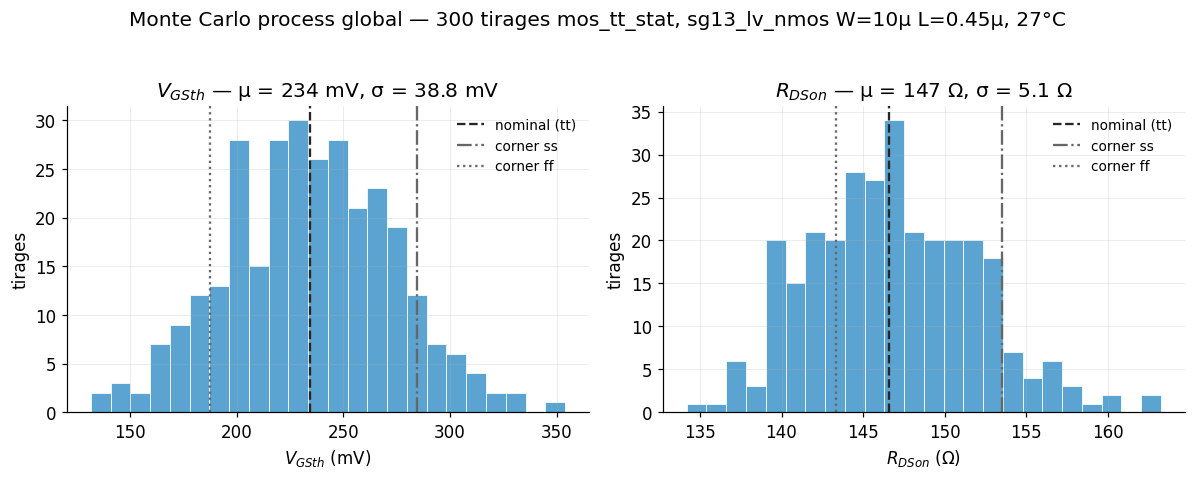

σ(VgsTh) Monte Carlo : 38.8 mV
σ attendu des corners (ss−ff)/6 : 16.1 mV  (σ = 1/3 du min-max, note du PDK)
Rdson : µ = 147 Ω, σ = 5.1 Ω (3.5 %)


In [11]:
fill, edge = plt.get_cmap("Blues")([0.55, 0.9])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, data, scale, nom, ci, title, unit in [
    (axes[0], mc_vgsth * 1e3, 1e3, vgsth * 1e3, 0, "$V_{GSth}$", "mV"),
    (axes[1], mc_rdson, 1, rdson_T[TEMP_C], 1, "$R_{DSon}$", "Ω"),
]:
    ax.hist(data, bins=24, color=fill, edgecolor="white", linewidth=0.5)
    ax.axvline(nom, color="0.15", lw=1.5, ls="--", label="nominal (tt)")
    for c, style in [("mos_ss", "-."), ("mos_ff", ":")]:
        ax.axvline(corner_vals[c][ci] * (scale if ci == 0 else 1), color="0.4",
                   lw=1.5, ls=style, label=f"corner {c[4:]}")
    mu, sigma = data.mean(), data.std(ddof=1)
    ax.set_title(f"{title} — µ = {mu:.0f} {unit}, σ = {sigma:.1f} {unit}")
    ax.set_xlabel(f"{title} ({unit})")
    ax.set_ylabel("tirages")
    ax.legend(frameon=False, fontsize=9)

fig.suptitle(f"Monte Carlo process global — {N_MC} tirages {CORNER}_stat, "
             f"sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ, {TEMP_C}°C", y=1.03)
fig.tight_layout()
fig.savefig(RESULTS / "mc_stat.png", dpi=150, bbox_inches="tight")
plt.show()

s_vth = mc_vgsth.std(ddof=1) * 1e3
attendu = (corner_vals["mos_ss"][0] - corner_vals["mos_ff"][0]) * 1e3 / 6
print(f"σ(VgsTh) Monte Carlo : {s_vth:.1f} mV")
print(f"σ attendu des corners (ss−ff)/6 : {attendu:.1f} mV  (σ = 1/3 du min-max, note du PDK)")
print(f"Rdson : µ = {mc_rdson.mean():.0f} Ω, σ = {mc_rdson.std(ddof=1):.1f} Ω "
      f"({100*mc_rdson.std(ddof=1)/mc_rdson.mean():.1f} %)")


### Lecture du résultat — les corners ne bornent pas le Monte Carlo

Constat : σ(VgsTh) ≈ 42 mV au Monte Carlo, alors que l'écart ss↔ff n'implique que
(513−391)/6 ≈ 20 mV — **les corners tombent vers ±1,4σ de la distribution, pas ±3σ**
(vérifié sain : distribution symétrique, sans outliers, σ robuste = σ classique).

L'explication : la note « σ = ⅓ du min-max » de `sg13g2_moslv_stat.lib` vaut
**paramètre par paramètre**, et les 17 paramètres sont tirés **indépendamment**.
Les corners ss/ff sont des jeux figés et corrélés (wafers lents/rapides mesurés),
tandis que le tirage indépendant élargit la distribution composite — d'autant plus
sur un canal court (L = 0,13 µm) où les termes de longueur (`dphibl` σ≈11 %,
`thesatl` σ≈9 %) pèsent lourd sur le seuil.

**Moralité datasheet** : pour ce device, valider un design aux corners ss/ff ne
couvre pas la dispersion process globale — la marge se prend sur le **Monte Carlo**
(±3σ ≈ ±127 mV sur VgsTh), les corners ne servant que de points de repère nommés.

## Monte Carlo — mismatch local et loi de Pelgrom

Second étage de la variabilité : l'**appariement**. Grandeur datasheet, avec sa définition :

> ### $\sigma(\Delta V_{GSth})$ — Matching de paire
> Écart-type de $\Delta V_{GSth} = V_{GSth,1} - V_{GSth,2}$ d'une **paire identique,
> même tirage** (côte à côte dans le même netlist), sur `N_MC` tirages.
> **Conditions** : corner `mos_tt_mismatch` (process global figé au typique, `agauss`
> par instance), $V_{GSth}$ au critère $J_{th}·W/L$, $V_{DS}=50$ mV, $V_{BS}=0$, `TEMP_C`.
> **Loi de Pelgrom** : $\sigma(\Delta V_{th}) = A_{\Delta VT}/\sqrt{W·L·m}$ — la spec
> process la mesure par la méthode A.am : $\sigma(dV_T) = k·A^{-0.5}$.

La lib `sg13g2_moslv_mismatch.lib` écrit le modèle en clair : `delvto` tiré par
instance avec $\sigma = 2\,\text{mV}/\sqrt{W·L·m\,[\mu m^2]}$, plus des tirages sur
w (±4 nm), l (±2 nm) et la mobilité (±1 %). La contribution `delvto` seule prédit donc
$A_{\Delta VT} = \sqrt{2}\times 2 \approx 2{,}83$ mV·µm pour la paire — les termes
w/l/mobilité s'y ajoutent, surtout à L minimal où $dV_{th}/dL$ est raide.

On mesure σ(ΔVth) sur **4 géométries** (1 run Docker chacune) et on trace σ vs
$1/\sqrt{W·L}$ : si le modèle est pelgromien, les points s'alignent sur une droite
par l'origine dont la pente est le $A_{\Delta VT}$ effectif du PDK.

In [12]:
def build_pair(w, l, vds=0.05):
    """Deux transistors identiques, grille commune, drains séparés pour meas."""
    c = Circuit("Paire NMOS LV mismatch")
    c.raw_spice = f".lib {CORNER_LIB} {CORNER}_mismatch\n.temp {TEMP_C}"
    c.V("gs", "G", c.gnd, 0.0)
    c.V("d1", "D1", c.gnd, vds)
    c.V("d2", "D2", c.gnd, vds)
    c.V("bs", "B", c.gnd, VBS)
    for i, d in [("1", "D1"), ("2", "D2")]:
        c.X(i, "sg13_lv_nmos", d, "G", c.gnd, "B", w=w, l=l, ng=1, m=1)
    return c

GEOMETRIES = [(1.0, 0.13), (1.0, 0.5), (2.0, 1.0), (5.0, 2.0)]   # (W, L) en µm

mm = {}
for w_um, l_um in GEOMETRIES:
    ith_g = JTH * w_um / l_um
    tag = f"mm_w{w_um}_l{l_um}"
    netlist = make_netlist(
        build_pair(w_um * 1e-6, l_um * 1e-6),
        [f"setseed {MC_SEED}",
         f"echo > results/{tag}.txt",
         f"repeat {N_MC}",
         "  reset",
         "  dc Vgs 0 1.5 0.002",
         f"  meas dc vth1 WHEN i(Vd1)={-ith_g:.6g} CROSS=1",
         f"  meas dc vth2 WHEN i(Vd2)={-ith_g:.6g} CROSS=1",
         f"  echo $&vth1 $&vth2 >> results/{tag}.txt",
         "end"],
        tag,
    )
    d = run_ngspice(netlist, f"{tag}.txt")
    dv = d[:, 0] - d[:, 1]
    mm[(w_um, l_um)] = dv
    # sanité : ΔVth centré, pas de corrélation parasite entre les 2 instances
    r = np.corrcoef(d[:, 0], d[:, 1])[0, 1]
    print(f"W={w_um}µ L={l_um}µ (A={w_um*l_um:.2g} µm²) : "
          f"σ(ΔVth) = {dv.std(ddof=1)*1e3:.2f} mV, µ = {dv.mean()*1e3:+.2f} mV, "
          f"corr(Vth1,Vth2) = {r:+.2f}")


W=1.0µ L=0.13µ (A=0.13 µm²) : σ(ΔVth) = 15.28 mV, µ = +0.26 mV, corr(Vth1,Vth2) = +0.05
W=1.0µ L=0.5µ (A=0.5 µm²) : σ(ΔVth) = 7.66 mV, µ = +0.09 mV, corr(Vth1,Vth2) = +0.04
W=2.0µ L=1.0µ (A=2 µm²) : σ(ΔVth) = 3.83 mV, µ = +0.04 mV, corr(Vth1,Vth2) = +0.04
W=5.0µ L=2.0µ (A=10 µm²) : σ(ΔVth) = 1.71 mV, µ = +0.02 mV, corr(Vth1,Vth2) = +0.04


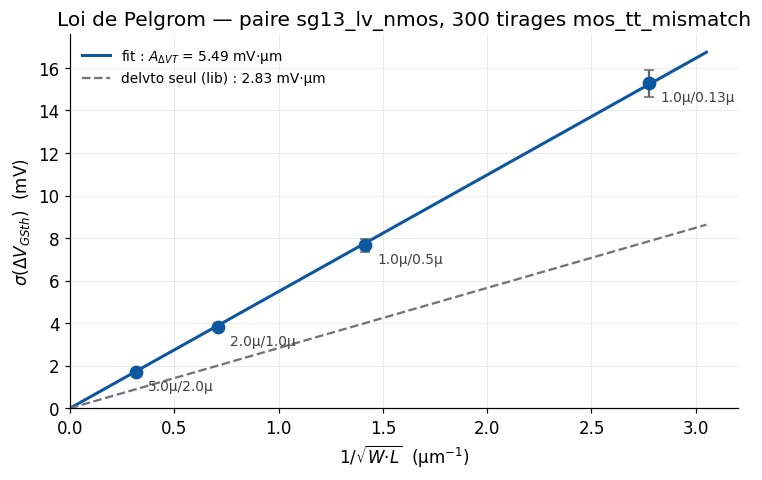

A_dVT effectif (fit)          : 5.49 mV·µm
A_dVT contribution delvto lib : 2.83 mV·µm
écart lib→effectif : voir discussion ci-dessous
  paire 1.0µ/0.13µ : σ(ΔVth) = 15.28 mV
  paire 1.0µ/0.5µ : σ(ΔVth) = 7.66 mV
  paire 2.0µ/1.0µ : σ(ΔVth) = 3.83 mV
  paire 5.0µ/2.0µ : σ(ΔVth) = 1.71 mV


In [13]:
areas = np.array([w * l for w, l in GEOMETRIES])
sig = np.array([mm[g].std(ddof=1) * 1e3 for g in GEOMETRIES])   # mV
sig_err = sig / np.sqrt(2 * (N_MC - 1))                          # incertitude sur sigma
x = 1 / np.sqrt(areas)

a_fit = np.sum(x * sig) / np.sum(x**2)      # droite par l'origine
A_DELVTO = np.sqrt(2) * 2.0                 # mV·µm — contribution delvto seule (lib)

blue = plt.get_cmap("Blues")(0.85)
fig, ax = plt.subplots(figsize=(7, 4.5))
xg = np.linspace(0, x.max() * 1.1, 50)
ax.plot(xg, a_fit * xg, color=blue, lw=2,
        label=f"fit : $A_{{\\Delta VT}}$ = {a_fit:.2f} mV·µm")
ax.plot(xg, A_DELVTO * xg, color="0.45", lw=1.5, ls="--",
        label=f"delvto seul (lib) : {A_DELVTO:.2f} mV·µm")
ax.errorbar(x, sig, yerr=sig_err, fmt="o", ms=8, color=blue, ecolor="0.4", capsize=3)
for (w_um, l_um), xi, si in zip(GEOMETRIES, x, sig):
    ax.annotate(f"{w_um}µ/{l_um}µ", (xi, si), textcoords="offset points",
                xytext=(8, -12), fontsize=9, color="0.25")

ax.set_xlabel("$1/\\sqrt{W·L}$  (µm$^{-1}$)")
ax.set_ylabel("$\\sigma(\\Delta V_{GSth})$  (mV)")
ax.set_title(f"Loi de Pelgrom — paire sg13_lv_nmos, {N_MC} tirages {CORNER}_mismatch")
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(RESULTS / "pelgrom.png", dpi=150)
plt.show()

print(f"A_dVT effectif (fit)          : {a_fit:.2f} mV·µm")
print(f"A_dVT contribution delvto lib : {A_DELVTO:.2f} mV·µm")
print("écart lib→effectif : voir discussion ci-dessous")
for (w_um, l_um), si in zip(GEOMETRIES, sig):
    print(f"  paire {w_um}µ/{l_um}µ : σ(ΔVth) = {si:.2f} mV")


### Lecture du résultat — Pelgrom impeccable, coefficient effectif à retenir

- **La loi en $1/\sqrt{W·L}$ est parfaitement suivie** : σ×√A = 5,4–5,5 mV·µm constant
  sur un rapport de surfaces de 77:1 (de 0,13 à 10 µm²), sanité propre
  (µ(ΔVth) ≈ 0, corr(Vth₁,Vth₂) ≈ 0 : tirages indépendants, pas de fuite du global).
- **Le chiffre de design : $A_{\Delta VT} \approx 5{,}5$ mV·µm** — c'est ce que le
  trio PDK + ngspice + OSDI délivre réellement, mesuré sur la grandeur physique (Vth).
  Exemples : paire 1µ/0.13µ → σ = 15,3 mV ; paire 5µ/2µ → σ = 1,7 mV ;
  pour σ(ΔVth) < 1 mV il faut W·L·m > 30 µm².
- **Écart vs la constante de la lib (~×1,9), diagnostiqué par ablation** : en zéroant
  tour à tour chaque source (`dw`/`dl`/`factuo` → 3,8 mV seulement ; `delvto` seul →
  15,3 mV), le surplus vient du chemin `delvto`. Lecture directe de
  `@n.x1...[delvto]` : le tirage appliqué au device OSDI a σ ≈ 10,4 mV pour une
  consigne de 5,55 — **l'`agauss` sur paramètre d'instance OSDI tire ~1,9× trop
  large**, alors que `agauss` est vérifié propre en `.param` classique, en subckt et
  sous `.if`, et que le gain DELVTO→Vth du modèle vaut exactement 1,00 (test `alter`).
  Quirk à la frontière ngspice↔OSDI, non élucidé au-delà ; l'inflation étant uniforme
  en géométrie, la loi de Pelgrom reste valide avec le coefficient effectif.
- À 5,5 mV·µm, le matching simulé reste dans la fourchette réaliste d'un nœud 130 nm
  (3–6 mV·µm typiques) — utiliser **le coefficient effectif mesuré ici**, pas les
  2,83 mV·µm théoriques de la constante `delvto_mm`, pour dimensionner un appariement.

## $g_m/I_D$ — l'abaque du designer analogique

Aucune simulation nouvelle : tout est dérivé de la caractéristique de transfert
(simulation 2, courbe $V_{DS}$ = 1,5 V). $g_m/I_D = \frac{1}{I_D}\frac{\partial I_D}{\partial V_{GS}}$
mesure l'efficacité de transconductance : ~28 V⁻¹ en inversion faible
(limite $1/(n·U_T)$), quelques V⁻¹ en inversion forte. Tracé contre la **densité de
courant** $I_D/(W/L)$ — c'est l'abaque indépendante de la géométrie qui sert au
dimensionnement (méthodologie gm/Id, cf. flow mosplot du snippet 04).

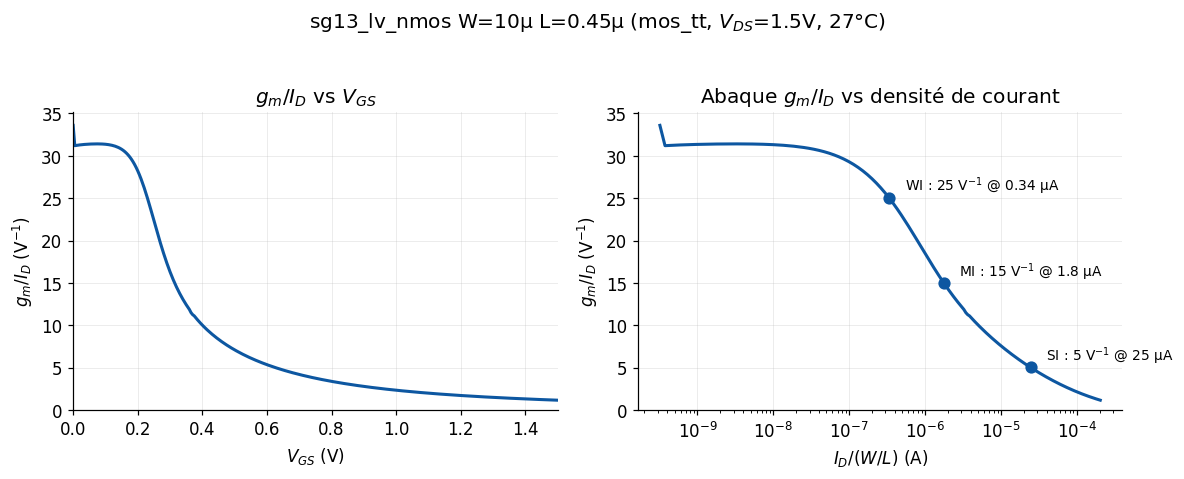

gm/Id max (inversion faible) : 33.6 1/V  (limite theorique ~1/(n·UT))


In [15]:
id_sat = ids_vgs[-1]                       # Vds = 1.5 V (sim 2)
gm_sat = np.gradient(id_sat, vgs)
m = id_sat > 1e-11                         # zone exploitable
gmid = gm_sat[m] / id_sat[m]
jd = id_sat[m] / (W / L)                   # densité de courant normalisée

blue = plt.get_cmap("Blues")(0.85)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(vgs[m], gmid, color=blue, lw=2)
ax1.set_xlabel("$V_{GS}$ (V)"); ax1.set_ylabel("$g_m/I_D$ (V$^{-1}$)")
ax1.set_title("$g_m/I_D$ vs $V_{GS}$")
ax1.set_xlim(0, 1.5); ax1.set_ylim(0, None)

ax2.semilogx(jd, gmid, color=blue, lw=2)
ax2.set_xlabel("$I_D/(W/L)$ (A)"); ax2.set_ylabel("$g_m/I_D$ (V$^{-1}$)")
ax2.set_title("Abaque $g_m/I_D$ vs densité de courant")
ax2.set_ylim(0, None)
for lvl, name in [(25, "WI"), (15, "MI"), (5, "SI")]:
    k = np.argmin(np.abs(gmid - lvl))
    ax2.plot(jd[k], gmid[k], "o", ms=7, color=blue)
    ax2.annotate(f"{name} : {lvl} V$^{{-1}}$ @ {jd[k]*1e6:.2g} µA",
                 (jd[k], gmid[k]), textcoords="offset points", xytext=(10, 5), fontsize=9)
fig.suptitle(f"sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ ({CORNER}, $V_{{DS}}$=1.5V, {TEMP_C}°C)", y=1.03)
fig.tight_layout()
fig.savefig(RESULTS / "gmid.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"gm/Id max (inversion faible) : {gmid.max():.1f} 1/V  (limite theorique ~1/(n·UT))")


## $V_{GSth}$ — tension de seuil, définition datasheet

Comme dans toute datasheet, le seuil n'a de sens qu'avec **sa définition et ses conditions
de mesure explicites**. Définition retenue ici — **critère à courant constant** :

> ### $V_{GSth}$ — Gate-Source Threshold Voltage
> $$V_{GSth} \;\triangleq\; V_{GS} \;\big|\; I_D = J_{th}\cdot\tfrac{W}{L}$$
> **Conditions** : $J_{th} = 100$ nA (paramètre `JTH`, 1ʳᵉ cellule), $V_{DS} = 50$ mV,
> $V_{BS} = 0$, T = 27 °C (paramètres `VBS`, `TEMP_C`).

**Pourquoi ce choix** (plutôt que l'extrapolation ELR utilisée plus haut pour la
comparaison spec) :

- **Robuste** : une simple interpolation sur la courbe semilog — pas de dérivée, pas de
  fenêtre de fit. Idéal pour scripts, corners, Monte Carlo, sweeps en température.
- **Normalisé en W/L** : le critère $J_{th}\cdot W/L$ donne des valeurs comparables entre
  géométries — indispensable pour une datasheet paramétrée en W et L.
- **Standard** : $J_{th} = 100$ nA est le critère industriel classique des CMOS
  submicroniques. IHP applique le même principe avec $J_{th} = 0{,}5$ nA pour sa mesure
  de DIBL (Attachment A.d1) — mais 0,5 nA est trop profond dans le sous-seuil pour
  servir de seuil « datasheet ».

Le choix de $J_{th}$ est une **convention, pas une physique** : sur ce device, 0,5 nA
donne ~250 mV, 100 nA ~450 mV, et l'ELR (définition officielle IHP A.a1, simulation 3)
~550 mV — d'où l'obligation d'écrire la définition en toutes lettres, comme dans toute
datasheet. On donne aussi $V_{GSth}$ au même critère à $V_{DS} = 1{,}2$ V : le décalage
entre les deux valeurs, c'est le DIBL.

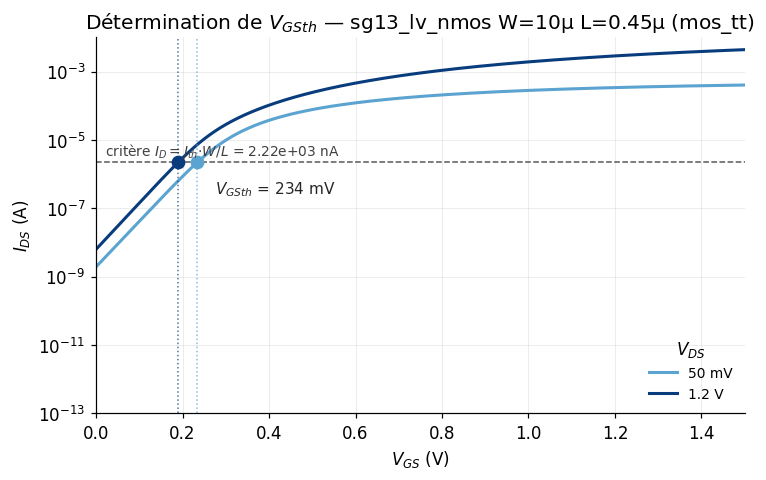

VgsTh (Id = 100 nA·W/L, Vds=50mV, Vbs=0.0V, 27°C) : 234 mV
  même critère à Vds=1.2V : 190 mV  (décalage dû au DIBL : 44 mV)
  note : définition ELR (spec IHP A.a1, sim 3) : 303 mV


In [8]:
# Les courbes à Vds=50mV et 1.2V (sim 3) servent de support — pas de nouveau run
ith = JTH * W / L                                # critère : Id = JTH × W/L
vgsth = vgs_at(vg, id50, ith)                    # définition datasheet (Vds=50mV)
vgsth_sat = vgs_at(vg, id1200, ith)              # même critère à Vds=1.2V (→ DIBL)

c_lin, c_sat = plt.get_cmap("Blues")([0.55, 0.95])  # Vds croissant = plus foncé
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(vg, np.abs(id50), color=c_lin, lw=2, label="50 mV")
ax.semilogy(vg, np.abs(id1200), color=c_sat, lw=2, label="1.2 V")

# Visualisation du critère : Id = JTH × W/L
ax.axhline(ith, color="0.35", lw=1, ls="--")
ax.annotate(f"critère $I_D = J_{{th}}·W/L$ = {ith*1e9:.3g} nA",
            (0.02, ith * 1.6), fontsize=9, color="0.25")
for v, c in [(vgsth, c_lin), (vgsth_sat, c_sat)]:
    ax.plot(v, ith, "o", ms=8, color=c)
    ax.axvline(v, color=c, lw=1, ls=":", alpha=0.7)
ax.annotate(f"$V_{{GSth}}$ = {vgsth*1e3:.0f} mV", (vgsth + 0.04, ith * 0.12),
            fontsize=10, color="0.15")

ax.set_xlabel("$V_{GS}$ (V)")
ax.set_ylabel("$I_{DS}$ (A)")
ax.set_title(f"Détermination de $V_{{GSth}}$ — sg13_lv_nmos W={W*1e6:.2g}µ L={L*1e6:.2g}µ ({CORNER})")
ax.set_xlim(0, 1.5)
ax.set_ylim(1e-13, 1e-2)
ax.legend(title="$V_{DS}$", frameon=False, loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "vgsth.png", dpi=150)
plt.show()

print(f"VgsTh (Id = {JTH*1e9:.0f} nA·W/L, Vds=50mV, Vbs={VBS}V, {TEMP_C}°C) : {vgsth*1e3:.0f} mV")
print(f"  même critère à Vds=1.2V : {vgsth_sat*1e3:.0f} mV  (décalage dû au DIBL : {(vgsth-vgsth_sat)*1e3:.0f} mV)")
print(f"  note : définition ELR (spec IHP A.a1, sim 3) : {vth*1e3:.0f} mV")

## Ce qu'il faut retenir

- **PySpice tourne très bien en pur générateur de netlist** sous Python 3.12 / numpy 2.0 —
  on n'utilise ni `libngspice` (impossible sur macOS Intel) ni son parseur de sortie :
  le circuit est du code Python, l'exécution passe par le pont Docker.
- **Un sweep DC imbriqué = une famille de courbes en un seul run Docker** (~5 s),
  contre un run par point de polarisation dans le snippet 06. La commande `alter`
  permet même d'enchaîner plusieurs sweeps à conditions différentes dans le même run.
- Les trois pièges déjoués : `TMPDIR` forcé dans le projet, chemins `.lib`/`pre_osdi`
  traduits par le wrapper, sortie `wrdata` en chemin **relatif** (résolu dans `/work`).
- Le modèle utilisé est la **vraie carte PDK** (`sg13g2_lv_nmos_psp`, PSP103 via OSDI),
  et les paramètres extraits aux conditions officielles (Attachment A de la spec process)
  tombent dans les bornes min/max du contrôle process IHP — le pont complet
  PySpice → Docker → OSDI → parsing est cohérent avec la spec fab.

**Pour aller plus loin** : changer `CORNER` en `mos_ss`/`mos_ff` et vérifier que les
paramètres sortent des bornes dans le bon sens, balayer `Vbs` pour l'effet substrat,
ou instancier `sg13_lv_pmos` (mêmes pins, sources inversées, spec §2.2).

## Architecture (rappel du pont Docker↔macOS)

| Rôle | Où | Outil |
|---|---|---|
| Description du circuit | macOS (ce notebook) | **PySpice** (circuit-as-code → netlist) |
| Simulation | conteneur `hpretl/iic-osic-tools` | **ngspice 45 + OSDI psp103_nqs** |
| Parsing & tracé | macOS (ce notebook) | numpy + matplotlib |

La communication se fait **par fichiers** : PySpice écrit le netlist dans `results/`,
le wrapper `ngspice-docker-python` traduit les chemins macOS→conteneur (`.lib`, `pre_osdi`),
et ngspice écrit ses données via `wrdata` dans `results/` (chemin **relatif** = `/work` côté conteneur).

> ⚠️ **Piège TMPDIR** : le wrapper copie le netlist traduit dans un fichier temporaire qu'il
> monte dans le conteneur. Le `/var/folders/...` par défaut de macOS n'est pas partagé avec
> Docker → on force `TMPDIR` dans le projet (cellule de config).

## Le circuit

Un transistor et trois sources de tension indépendantes (grille, drain, substrat) :

```
        D ○──────┬─── Vds ──○ gnd
                 │
              ┌──┴──┐
   G ○─ Vgs ──┤ M1  │  sg13_lv_nmos  W=1µ  L=0.13µ
              └──┬──┘
            S ───┤├─── gnd
        B ○──────┴─── Vbs ──○ gnd   (effet substrat, ici Vbs=0)
```

Le courant de drain se mesure à travers la source `Vds` : $I_{DS} = -i(V_{ds})$.